# 05 — Online learning on a frozen reservoir

The reservoir is fixed; only the **readout** adapts, **one sample at a time** via `OnlineReadout.partial_fit` (recursive least squares). Two things to see: (1) the readout learns as data streams in, and (2) a **forgetting factor** lets it track a *changing* target (concept drift) — the core of online continuous learning.

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); os.chdir(REPO)
import numpy as np, matplotlib.pyplot as plt

In [2]:
import random, pandas as pd
from reservoirs.random import Reservoir
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
labels = data[:,4:].argmax(1)
np.random.seed(7); res = Reservoir(4, 80, rhow=1.25)
states = np.stack([res.forward(s, collect_states=True) for s in u])   # [150,T,80]
print('reservoir states:', states.shape)

reservoir states: (150, 50, 80)


### Streaming learning curve (Iris)
Feed one flower at a time; watch held-out accuracy rise.

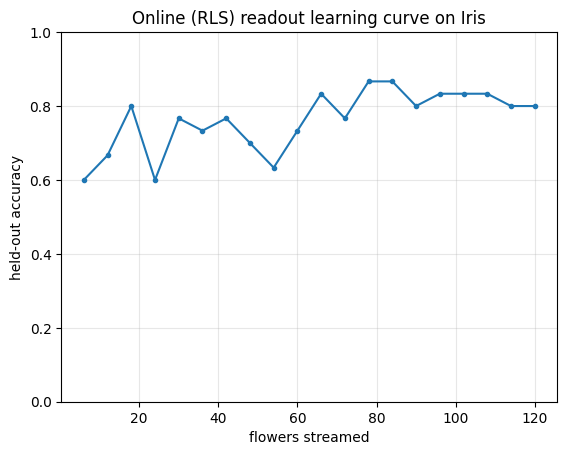

final streamed test accuracy: 0.8


In [3]:
from reservoirs.learning import OnlineReadout
feat = states.mean(1)                       # time-averaged reservoir state per flower
Xtr, ytr, Xte, yte = feat[tr], labels[tr], feat[te], labels[te]
order = np.random.default_rng(0).permutation(len(Xtr))
clf = OnlineReadout(forgetting=1.0, ridge=1e-4)
clf.partial_fit(Xtr[order[:1]], ytr[order[:1]], classes=[0,1,2])
xs, ys = [], []
for k, i in enumerate(order[1:], start=2):
    clf.partial_fit(Xtr[i:i+1], ytr[i:i+1])
    if k % 6 == 0:
        xs.append(k); ys.append(float(np.mean(clf.predict(Xte)==yte)))
plt.plot(xs, ys, marker='.'); plt.xlabel('flowers streamed'); plt.ylabel('held-out accuracy')
plt.title('Online (RLS) readout learning curve on Iris'); plt.ylim(0,1); plt.grid(alpha=.3); plt.show()
print('final streamed test accuracy:', round(ys[-1],3))

### Concept drift — the forgetting factor
The target map switches at t=200. `forgetting=1` (infinite memory) cannot adapt; `forgetting<1` weights recent data and tracks the change.

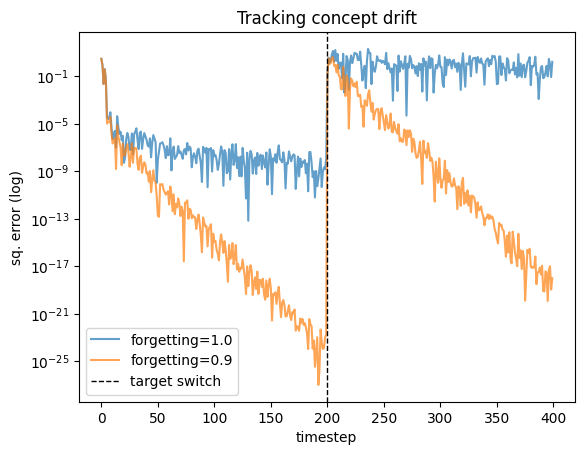

post-drift mean sq err  lam=1.0: 1.8779  lam=0.9: 0.0068


In [4]:
from reservoirs.learning import RLSReadout
g = np.random.default_rng(1); f = 4
W1, W2 = g.standard_normal((f,1)), g.standard_normal((f,1))
def run(forget):
    r = RLSReadout(f, 1, forgetting=forget, ridge=1e-2); err = []
    gg = np.random.default_rng(42)
    for t in range(400):
        x = gg.standard_normal((1,f)); W = W1 if t < 200 else W2; d = x @ W
        err.append(float(np.mean((d - r.predict(x))**2))); r.partial_fit(x, d)
    return np.array(err)
e_inf, e_forget = run(1.0), run(0.9)
plt.plot(e_inf, label='forgetting=1.0', alpha=.7); plt.plot(e_forget, label='forgetting=0.9', alpha=.7)
plt.axvline(200, color='k', ls='--', lw=1, label='target switch'); plt.yscale('log')
plt.xlabel('timestep'); plt.ylabel('sq. error (log)'); plt.legend(); plt.title('Tracking concept drift'); plt.show()
print('post-drift mean sq err  lam=1.0:', round(e_inf[210:].mean(),4), ' lam=0.9:', round(e_forget[210:].mean(),4))

**Takeaway:** `forgetting=1` is exact recursive least squares (best for a *stationary* target); `forgetting<1` trades steady-state precision for the ability to **track non-stationary** streams. This is the online axis of continuous learning.